# The plan

The plan to test how can we improve the performance of the simulation of the phase protocol. We shall try both simplifying the initializer and de-initializers for the secondary register, as well as trying out things other than the aer simulator like the estimators and the like.


In [37]:
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Statevector, random_statevector
import numpy as np
from qiskit.circuit.library import StatePreparation
from qiskit_encore.preparable_statevector import GenericQiskitPreparableStatevector

In [38]:
phi = random_statevector(4)
phi

Statevector([ 0.19200351-0.05436922j, -0.37019272+0.30210931j,
              0.7185356 +0.07126355j,  0.42913141-0.16229691j],
            dims=(2, 2))


In [39]:
prep = StatePreparation(phi)
de_prep = prep.inverse()

In [40]:
circ0 = QuantumCircuit(prep.num_qubits)
circ0.append(prep, circ0.qubits)
# circ0.draw()

In [41]:
output = Statevector.from_instruction(circ0)
np.allclose(output.data, phi.data)

True

In [42]:
circ0.append(de_prep, circ0.qubits)

In [43]:
output = Statevector.from_instruction(circ0)
output

Statevector([1.00000000e+00-2.30125724e-16j,
             1.25016090e-17-1.20196160e-16j,
             1.33446107e-17-1.37852318e-17j,
             8.17139865e-17+2.37409513e-17j],
            dims=(2, 2))


In [44]:
prepable = GenericQiskitPreparableStatevector.from_statevector(phi)

Using generic qiskit state initializer.
qiskit inverse de-initializer


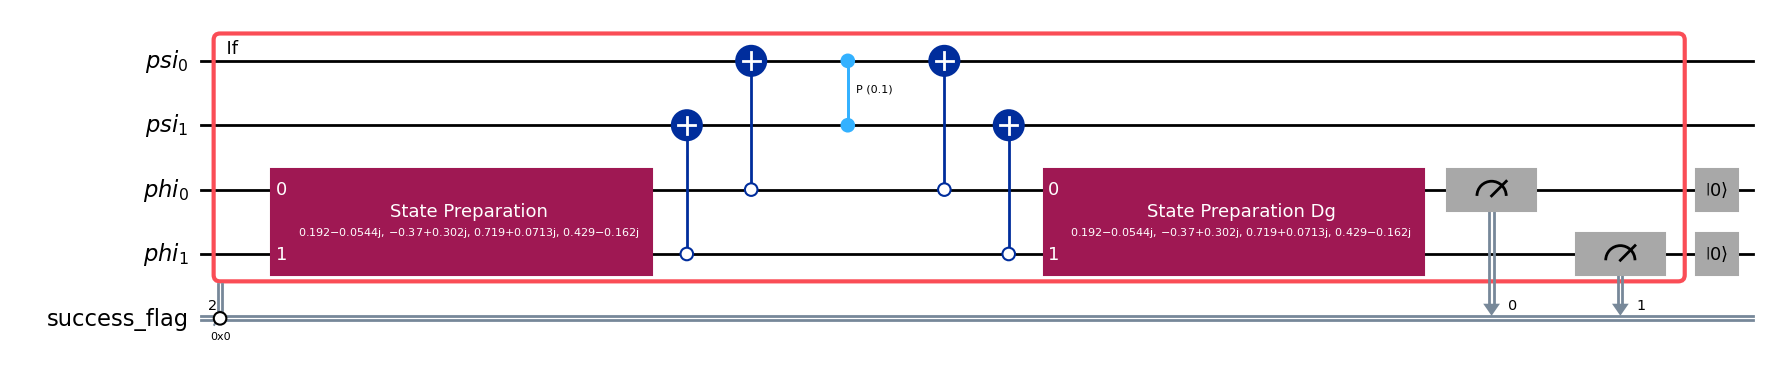

In [45]:
psi_reg = QuantumRegister(prep.num_qubits, "psi")
phi_reg = QuantumRegister(prep.num_qubits, "phi")
success_flag = ClassicalRegister(prep.num_qubits, "success_flag")
circ1 = QuantumCircuit(psi_reg, phi_reg, success_flag)

delta = 0.1

with circ1.if_test((success_flag, 0)) as else_:
    circ1.compose(prepable.initializer_circuit, phi_reg, inplace=True)

    # Step 2: the partial phase operator
    # Flag qubit computation
    for i in range(psi_reg.size):
        circ1.cx(
            phi_reg[psi_reg.size - 1 - i],
            psi_reg[psi_reg.size - 1 - i],
            ctrl_state=0,
        )

    # The application of the phase
    circ1.mcp(delta, psi_reg[0:-1], psi_reg[-1])

    # "Un-computing" the flag qubits
    for i in range(psi_reg.size):
        circ1.cx(phi_reg[i], psi_reg[i], ctrl_state=0)

    # Step 3: partial measurement of the secondary register
    circ1.compose(prepable.de_initializer_circuit, phi_reg, inplace=True)
    circ1.measure(phi_reg, success_flag)

circ1.reset(phi_reg)

circ1.draw("mpl")

In [46]:
output = Statevector.from_instruction(circ1)
output

QiskitError: 'Circuits with control flow operations cannot be converted to an instruction.'

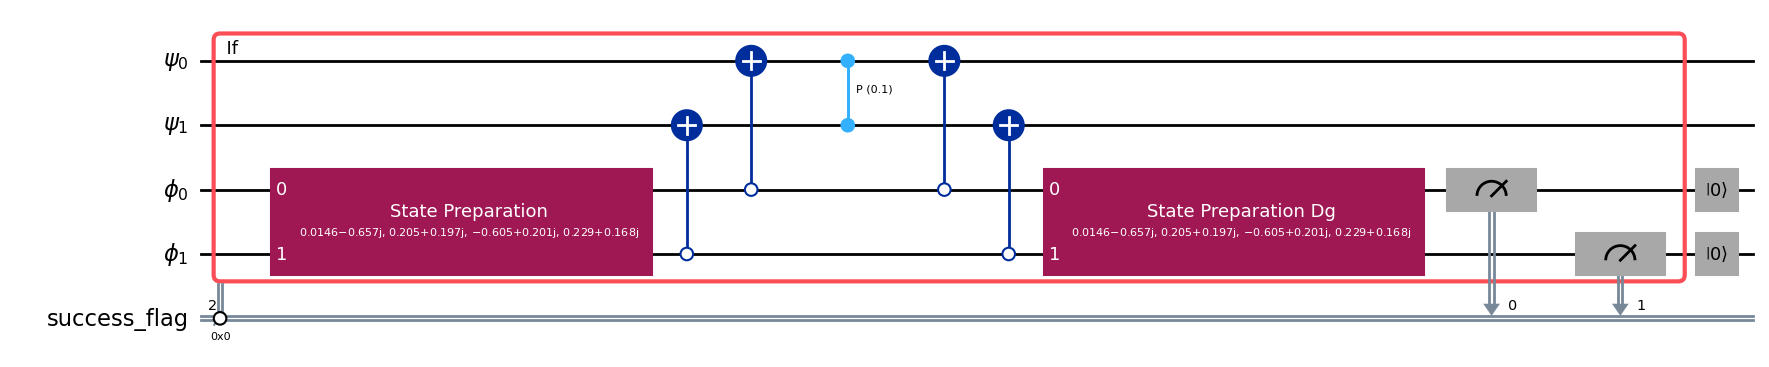

In [ ]:
from qiskit_phase_propagator.sample_based import (
    GenericIterativeSampleBasedPhasePropagator,
)


circ2 = GenericIterativeSampleBasedPhasePropagator.from_state(prepable, [delta])

circ2.draw("mpl")

In [ ]:
output = Statevector.from_instruction(circ2)
output

QiskitError: 'Circuits with control flow operations cannot be converted to an instruction.'